# Task 1: Time Series Analysis

            Value
Date             
2020-01-01    100
2020-01-02    120
2020-01-03    130
2020-01-04    125
2020-01-05    140


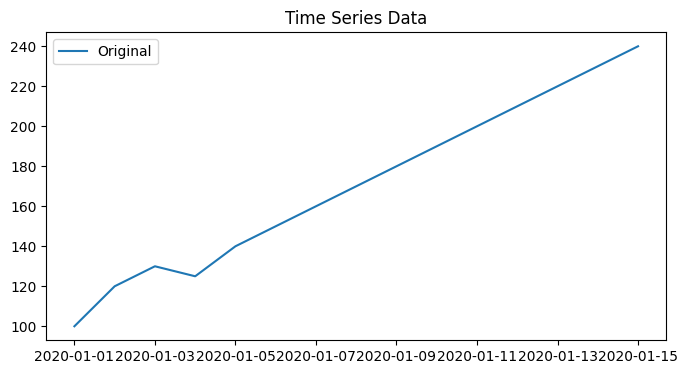


RMSE: 2.322411279511042


C:\Users\smrut\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


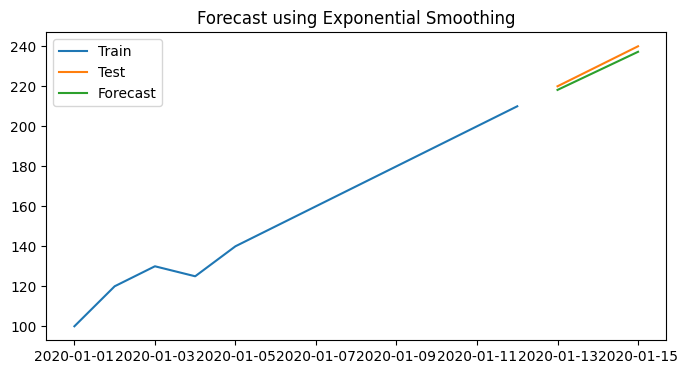

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import numpy as np
df = pd.read_csv("../DATASETS/timeseries.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())
plt.figure(figsize=(8,4))
plt.plot(df['Value'], label='Original')
plt.title("Time Series Data")
plt.legend()
plt.show()
train_size = int(len(df) * 0.8)
train = df['Value'][:train_size]
test = df['Value'][train_size:]
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

model_fit = model.fit()
forecast = model_fit.forecast(len(test))
rmse = np.sqrt(mean_squared_error(test, forecast))
print("\nRMSE:", rmse)
plt.figure(figsize=(8,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.title("Forecast using Exponential Smoothing")
plt.show()